# Performance Benchmark: DuckReg vs Pyfixest

Benchmarks **running time** across N × K × nFE × model type × package.

### Files
| File | Role |
|------|------|
| [`scripts/run_single.py`](scripts/run_single.py) | Runs one (package, model, N, K, nFE) combination; writes `results/<key>.json` |
| [`scripts/run_single_benchmark.sh`](scripts/run_single_benchmark.sh) | SLURM wrapper — invoked by orchestrator |
| [`scripts/orchestrate.py`](scripts/orchestrate.py) | Submits jobs (max 4 concurrent), tracks `results/manifest.csv`, waits for completion |
| [`scripts/collect_results.py`](scripts/collect_results.py) | Merges JSON results; flags OOM kills from `.err` logs |

**Cell 2** checks for `results/benchmark_results_large.csv`.  
- If found → loads and displays.  
- If not → runs `python scripts/orchestrate.py` (which submits jobs and waits) then collects.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 1. Check Results / Submit Benchmark Jobs

In [2]:
import subprocess
from pathlib import Path

BENCH_DIR   = Path(".")
RESULTS_CSV = BENCH_DIR / "benchmark_results_20260305_121124.csv"

results = None

if RESULTS_CSV.exists():
    results = pd.read_csv(RESULTS_CSV)
    n_ok  = (results["status"] == "success").sum()
    n_oom = (results["status"] == "oom_killed").sum()
    n_fail = (results["status"] == "failed").sum()
    print(f"Results loaded from {RESULTS_CSV}  ({len(results)} rows)")
    print(f"  success={n_ok}  oom_killed={n_oom}  failed={n_fail}")
    display(results)
else:
    print(f"No results at {RESULTS_CSV}.")
    print("Launching orchestrate.py — submitting SLURM jobs (max 4 concurrent) and waiting …")
    proc = subprocess.run(
        ["python", "scripts/orchestrate.py", "--results-dir", "results"],
        cwd=str(BENCH_DIR),
    )
    if proc.returncode == 0 and RESULTS_CSV.exists():
        results = pd.read_csv(RESULTS_CSV)
        print(f"\nDone.  {len(results)} rows collected.")
        display(results)
    else:
        print("orchestrate.py finished.  Re-run this cell to load results.")

Results loaded from benchmark_results_20260305_121124.csv  (864 rows)
  success=626  oom_killed=182  failed=22


,package,model_type,N,K,nFE1,nFE2,vcov,threads,job_id,status,time_seconds,error,slurm_error
0,duckreg,fe,100000000,5,100000,100000,CRV1,1,7123845,failed,NaN,IO Error: Could not read enough bytes from fil...,NaN
1,duckreg,fe,100000000,5,100000,100000,CRV1,4,7123869,failed,NaN,IO Error: Could not read enough bytes from fil...,NaN
2,duckreg,fe,100000000,5,100000,100000,HC1,4,7123841,failed,NaN,IO Error: Could not read enough bytes from fil...,NaN
3,duckreg,fe,100000000,5,10000,10000,CRV1,1,7123248,failed,NaN,IO Error: Could not read enough bytes from fil...,NaN
4,duckreg,fe,100000000,5,10000,10000,CRV1,4,7123264,failed,NaN,IO Error: Could not read enough bytes from fil...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,duckreg,iv,100000000,20,100000,100000,CRV1,4,7125490,oom_killed,NaN,OOM killed,/var/spool/slurm/job7125490/slurm_script: line...
860,pyfixest,iv,100000000,20,100000,100000,HC1,1,7125491,oom_killed,NaN,OOM killed,/var/spool/slurm/job7125491/slurm_script: line...
861,pyfixest,iv,100000000,20,100000,100000,HC1,4,7125492,oom_killed,NaN,OOM killed,/var/spool/slurm/job7125492/slurm_script: line...
862,pyfixest,iv,100000000,20,100000,100000,CRV1,1,7125538,oom_killed,NaN,OOM killed,/var/spool/slurm/job7125538/slurm_script: line...


## 2. Visualize Results

Non-success runs:


,package,model_type,N,K,nFE1,status,error,job_id
0,duckreg,fe,100000000,5,100000,failed,IO Error: Could not read enough bytes from fil...,7123845
1,duckreg,fe,100000000,5,100000,failed,IO Error: Could not read enough bytes from fil...,7123869
2,duckreg,fe,100000000,5,100000,failed,IO Error: Could not read enough bytes from fil...,7123841
3,duckreg,fe,100000000,5,10000,failed,IO Error: Could not read enough bytes from fil...,7123248
4,duckreg,fe,100000000,5,10000,failed,IO Error: Could not read enough bytes from fil...,7123264
...,...,...,...,...,...,...,...,...
859,duckreg,iv,100000000,20,100000,oom_killed,OOM killed,7125490
860,pyfixest,iv,100000000,20,100000,oom_killed,OOM killed,7125491
861,pyfixest,iv,100000000,20,100000,oom_killed,OOM killed,7125492
862,pyfixest,iv,100000000,20,100000,oom_killed,OOM killed,7125538


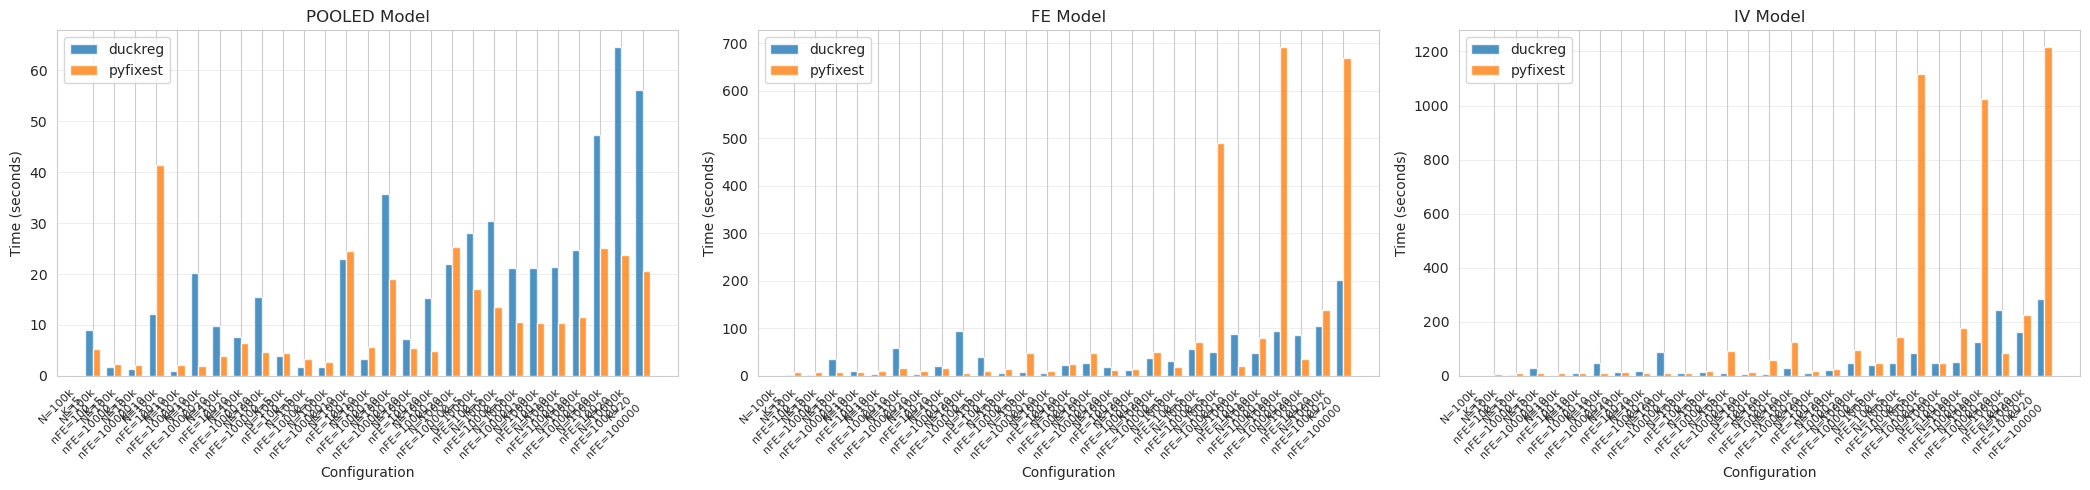

package,N,K,nFE1,model_type,duckreg,pyfixest,speedup
0,100000,5,100,fe,2.921150,8.236650,2.819660
1,100000,5,100,iv,1.070600,8.708675,8.134387
2,100000,5,100,pooled,8.946400,5.201375,0.581393
3,100000,5,10000,fe,2.372775,8.773625,3.697622
4,100000,5,10000,iv,4.340375,10.249175,2.361357
...,...,...,...,...,...,...,...
76,10000000,20,10000,iv,161.660700,224.747900,1.390245
77,10000000,20,10000,pooled,64.560400,23.790025,0.368493
78,10000000,20,100000,fe,202.845175,668.796275,3.297078
79,10000000,20,100000,iv,282.982850,1217.215350,4.301375


In [3]:
if results is None:
    print("No results — run cell 1 first.")
else:
    df_ok = results[results["status"] == "success"].copy()

    # OOM / failure summary
    df_bad = results[results["status"] != "success"]
    if not df_bad.empty:
        print("Non-success runs:")
        display(df_bad[["package", "model_type", "N", "K", "nFE1", "status", "error", "job_id"]])

    if df_ok.empty:
        print("No successful runs to plot yet.")
    else:
        def plot_time_comparison(df_ok):
            pivot = df_ok.pivot_table(
                values="time_seconds",
                index=["N", "K", "nFE1", "model_type"],
                columns="package",
                aggfunc="mean",
            ).reset_index()
            for pkg in ("duckreg", "pyfixest"):
                if pkg not in pivot.columns:
                    pivot[pkg] = float("nan")
            pivot["speedup"] = pivot["pyfixest"] / pivot["duckreg"]

            model_types = [m for m in ["pooled", "fe", "iv"]
                           if m in pivot["model_type"].unique()]
            fig, axes = plt.subplots(1, len(model_types),
                                     figsize=(7 * len(model_types), 5))
            if len(model_types) == 1:
                axes = [axes]

            for ax, mt in zip(axes, model_types):
                data = pivot[pivot["model_type"] == mt].sort_values(["N", "K"])
                if data.empty:
                    continue
                x_labels = [
                    f"N={r['N']//1000}k\nK={r['K']}\nnFE={r['nFE1']}"
                    for _, r in data.iterrows()
                ]
                x = np.arange(len(x_labels))
                w = 0.35
                ax.bar(x - w/2, data["duckreg"],  w, label="duckreg",  alpha=0.8)
                ax.bar(x + w/2, data["pyfixest"], w, label="pyfixest", alpha=0.8)
                ax.set_xlabel("Configuration")
                ax.set_ylabel("Time (seconds)")
                ax.set_title(f"{mt.upper()} Model")
                ax.set_xticks(x)
                ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8)
                ax.legend()
                ax.grid(axis="y", alpha=0.3)

            plt.tight_layout()
            plt.savefig("benchmark_time_comparison.png", dpi=150, bbox_inches="tight")
            plt.show()
            return pivot

        pivot = plot_time_comparison(df_ok)
        display(pivot[["N", "K", "nFE1", "model_type", "duckreg", "pyfixest", "speedup"]])

## 3. Summary Statistics

In [4]:
if results is None:
    print("No results — run cell 1 first.")
else:
    df_ok = results[results["status"] == "success"].copy()

    if df_ok.empty:
        print("No successful runs yet.")
    else:
        # Time summary
        time_summary = df_ok.groupby(["package", "model_type"]).agg(
            time_mean=("time_seconds", "mean"),
            time_std =("time_seconds", "std"),
            time_min =("time_seconds", "min"),
            time_max =("time_seconds", "max"),
            n        =("time_seconds", "count"),
        ).round(2)
        print("Time summary by package and model type:")
        display(time_summary)

        # Speedup
        speedup = df_ok.pivot_table(
            values="time_seconds",
            index=["model_type", "N", "K", "nFE1"],
            columns="package",
        ).reset_index()
        if "duckreg" in speedup.columns and "pyfixest" in speedup.columns:
            speedup["speedup"] = speedup["pyfixest"] / speedup["duckreg"]
            print("\nAverage speedup (pyfixest / duckreg) by model type:")
            display(speedup.groupby("model_type")["speedup"].mean().round(2))
            print(f"\nOverall average speedup: {speedup['speedup'].mean():.2f}x")

    # Status summary across all runs
    print("\nAll runs by status:")
    display(results.groupby(["package", "status"]).size().rename("count").reset_index())

Time summary by package and model type:


time_mean  time_std  time_min  time_max   n
package  model_type                                             
duckreg  fe              69.05     92.98      2.82    299.23  27
         iv             134.60    185.05      2.74    584.96  30
         pooled          16.80     23.18      0.71     74.36  27
pyfixest fe              10.32      8.03      4.06     30.92  27
         iv              15.54     12.48      5.95     45.10  24
         pooled           4.46      4.73      0.88     15.55  27


Average speedup (pyfixest / duckreg) by model type:


model_type
fe        0.48
iv        0.67
pooled    0.55
Name: speedup, dtype: float64


Overall average speedup: 0.56x

All runs by status:


,package,status,count
0,duckreg,missing,24
1,duckreg,success,84
2,pyfixest,missing,30
3,pyfixest,success,78
